Loading oed_training_data_job0.pkl...

DATA SUMMARY
Type of data: <class 'dict'>
Job ID: 0
Number of samples: 1
Found 1 samples in 'samples' key

First sample keys: ['seed', 'c_init', 'speed_left', 'speed_right', 'coeffs_left', 'coeffs_right', 'wind_params', 'nn_input', 'wind_dof_vector', 'm_opt', 'eig_K1', 'eig_K2', 'eig_K3', 'pen_K3', 'nfev_total', 'time']

STATISTICS
EIG K=1:
  Mean: 21.936
  Std:  0.000
  Min:  21.936
  Max:  21.936

EIG K=2:
  Mean: 23.251
  Std:  0.000

EIG K=3:
  Mean: 23.365
  Std:  0.000
  Min:  23.365
  Max:  23.365

EIG Gain (K3 - K1):
  Mean: 1.428
  Std:  0.000
  Min:  1.428
  Max:  1.428

Optimization time (seconds):
  Mean: 774.4
  Std:  0.0
  Min:  774.4
  Max:  774.4

Function evaluations:
  Mean: 621.0
  Std:  0.0

Penalty K3:
  Mean: 0.0157
  Std:  0.0000

FIRST 3 SAMPLES

Sample 0:
  seed: 1775614002
  c_init: [0.559, 0.440]
  speed_left: 1.428
  speed_right: 0.714
  eig_K1: 21.936
  eig_K2: 23.251
  eig_K3: 23.365
  pen_K3: 0.0157
  nfev_total: 621

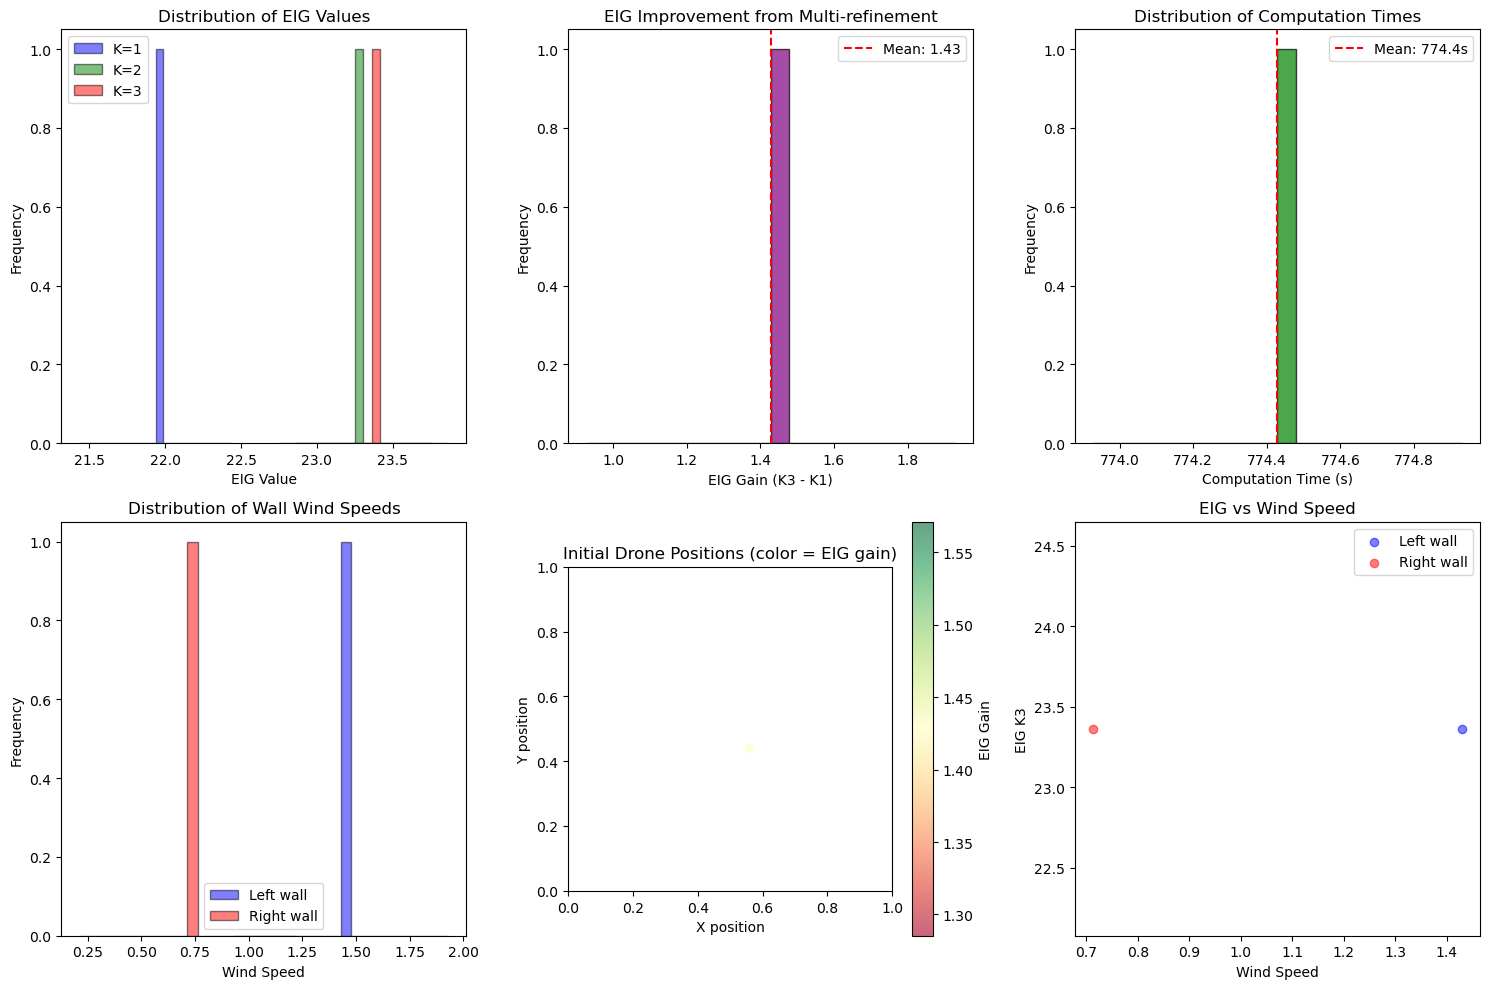


SAMPLE VISUALIZATION
Setting up mesh and initial concentration...

Visualizing sample 0:
  seed: 1775614002
  c_init: [0.559, 0.440]
  speed_left: 1.428
  speed_right: 0.714
  eig_K1: 21.936
  eig_K2: 23.251
  eig_K3: 23.365
  pen_K3: 0.0157
  Reconstructing wind field...
  Generating plot...
  Saved plot to viz/sample_0_visualization.png


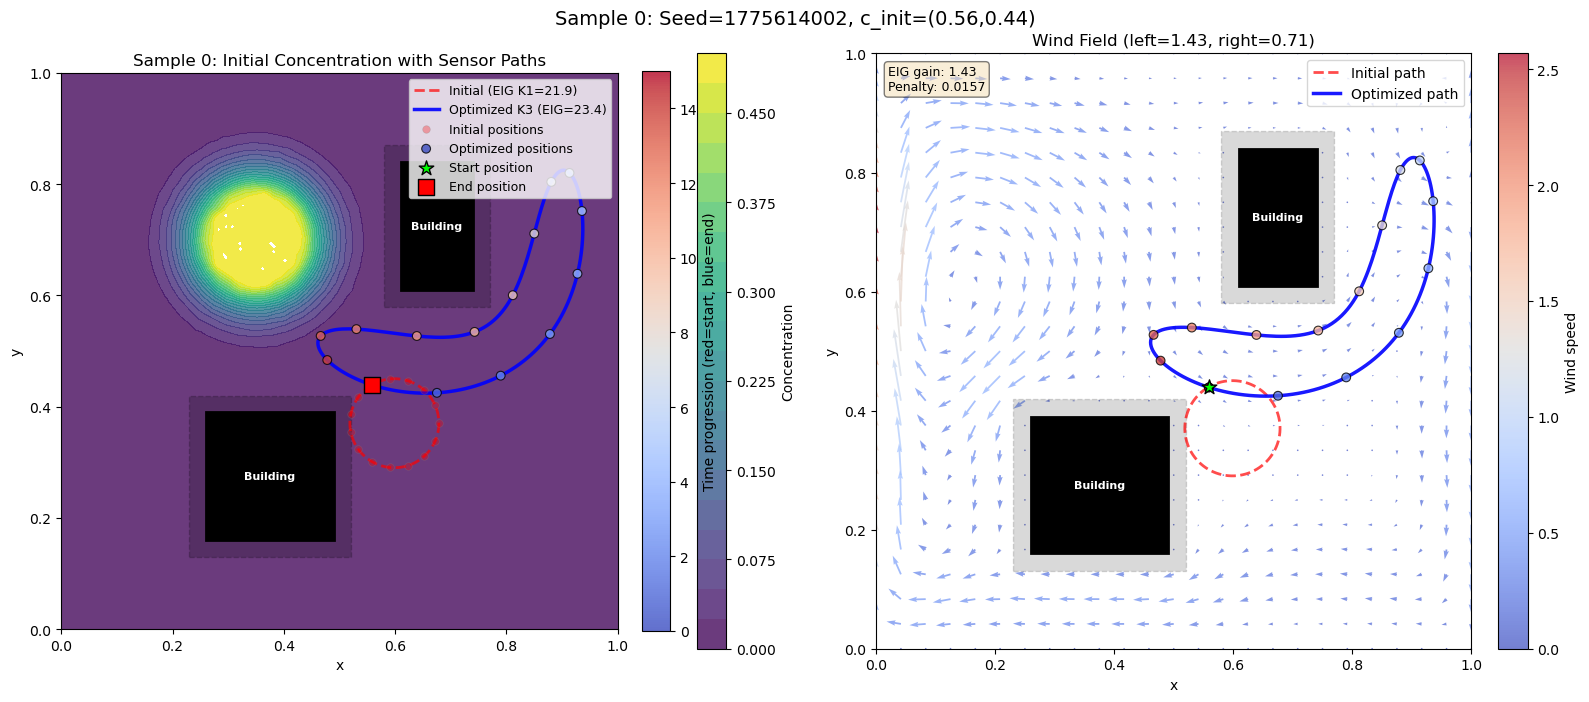

Invalid input. Please enter a number or 'q'.


In [5]:
#!/usr/bin/env python3
"""
Script to read and inspect the OED training data pickle file.
Allows visualization of specific samples with initial/optimized paths, wind field, and concentration.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import dolfin as dl
import sys
import os

# Add paths for hippylib and model_ad_diff if needed
sys.path.append(os.environ.get('HIPPYLIB_BASE_DIR', "../../"))
from hippylib import *

sys.path.append('../../')
from model_ad_diff_bwd import TimeDependentAD

# Import our modules
from fourier_utils import generate_targets, fourier_frequencies
from config import TY, K, OBSERVATION_TIMES, SIMULATION_TIMES, NOISE_VARIANCE
MESH_FILE = 'ad_20.xml'

# Suppress FEniCS logging
import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

def reconstruct_wind_from_dofs(mesh, wind_dof_vector):
    """Reconstruct wind velocity field from DOF vector."""
    # Create vector function space
    Xh = dl.VectorFunctionSpace(mesh, 'Lagrange', 2)
    wind_velocity = dl.Function(Xh)
    wind_velocity.vector().set_local(wind_dof_vector)
    wind_velocity.vector().apply("")
    # Allow extrapolation for visualization
    wind_velocity.set_allow_extrapolation(True)
    return wind_velocity

def create_initial_guess_from_c0(c0, K_stage):
    """Create initial guess from c0 (starting position)."""
    from config import TY, OBSERVATION_TIMES
    omegas = fourier_frequencies(TY, K_stage)
    m0 = np.zeros(4 * K_stage + 2)
    
    # Simple circular motion as initial guess
    radius = 0.08
    m0[2] = radius  # cos coefficient for x
    m0[3] = 0.0     # sin coefficient for x
    m0[4] = 0.0     # cos coefficient for y
    m0[5] = radius  # sin coefficient for y
    
    # Fix initial position to c0
    t0_obs = OBSERVATION_TIMES[0]
    shift_x = 0.0
    shift_y = 0.0
    for k in range(K_stage):
        cos_kt = np.cos(omegas[k] * t0_obs)
        sin_kt = np.sin(omegas[k] * t0_obs)
        shift_x += m0[2 + 4*k] * cos_kt + m0[3 + 4*k] * sin_kt
        shift_y += m0[4 + 4*k] * cos_kt + m0[5 + 4*k] * sin_kt
    m0[0] = c0[0] - shift_x
    m0[1] = c0[1] - shift_y
    
    return m0

def plot_wind_field_on_grid(ax, wind_velocity, mesh, resolution=20):
    """Plot wind field on a regular grid to avoid interpolation issues."""
    # Create regular grid
    x = np.linspace(0, 1, resolution)
    y = np.linspace(0, 1, resolution)
    X, Y = np.meshgrid(x, y)
    
    # Evaluate wind velocity at grid points
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(resolution):
        for j in range(resolution):
            point = np.array([X[i,j], Y[i,j]])
            try:
                # Try to evaluate at point
                val = wind_velocity(point)
                U[i,j] = val[0]
                V[i,j] = val[1]
            except:
                # If point is outside, use nearest valid value
                closest_point = np.clip(point, 0.001, 0.999)
                try:
                    val = wind_velocity(closest_point)
                    U[i,j] = val[0]
                    V[i,j] = val[1]
                except:
                    U[i,j] = 0
                    V[i,j] = 0
    
    # Compute speed
    speed = np.sqrt(U**2 + V**2)
    
    # Plot quiver with color
    quiver = ax.quiver(X, Y, U, V, speed, 
                       cmap='coolwarm', alpha=0.7, 
                       scale=15, width=0.003)
    
    return quiver

def plot_buildings(ax, buildings, alpha=0.3):
    """Plot building obstacles on the axis."""
    for building in buildings:
        xmin, ymin = building['lower']
        xmax, ymax = building['upper']
        margin = building.get('margin', 0.0)
        
        # Plot the margin area (lighter)
        if margin > 0:
            margin_rect = plt.Rectangle(
                (xmin - margin, ymin - margin),
                (xmax - xmin + 2*margin),
                (ymax - ymin + 2*margin),
                facecolor='black', alpha=alpha*0.5, 
                edgecolor='black', linewidth=1, linestyle='--'
            )
            ax.add_patch(margin_rect)
        
        # Plot the building itself (darker)
        building_rect = plt.Rectangle(
            (xmin, ymin),
            (xmax - xmin),
            (ymax - ymin),
            facecolor='black', 
            edgecolor='black', linewidth=2
        )
        ax.add_patch(building_rect)
        
        # Add building label
        ax.text(xmin + (xmax-xmin)/2, ymin + (ymax-ymin)/2,
                'Building', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

def setup_initial_concentration_only(mesh):
    """Create only the initial concentration field without any other FE setup."""
    Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
    
    # Create the initial concentration expression (Gaussian blob)
    ic_expr = dl.Expression(
        'std::min(0.5, std::exp(-100*(std::pow(x[0]-0.35,2) + std::pow(x[1]-0.7,2))))',
        element=Vh.ufl_element()
    )
    
    true_ic_vector = dl.interpolate(ic_expr, Vh).vector()
    true_ic_function = dl.Function(Vh, true_ic_vector)
    
    return Vh, true_ic_function

# Load the data
filename = 'oed_training_data_job0.pkl'
print(f"Loading {filename}...")

with open(filename, 'rb') as f:
    data = pickle.load(f)

print(f"\n{'='*60}")
print(f"DATA SUMMARY")
print(f"{'='*60}")
print(f"Type of data: {type(data)}")
print(f"Job ID: {data.get('job_id', 'N/A')}")
print(f"Number of samples: {data.get('n_samples', len(data.get('samples', [])))}")

# Extract samples
if 'samples' in data:
    samples = data['samples']
    buildings = data.get('buildings', [])
    print(f"Found {len(samples)} samples in 'samples' key")
else:
    samples = data if isinstance(data, list) else []
    buildings = []
    print(f"Data is a list of {len(samples)} samples")

if len(samples) == 0:
    print("No samples found. Exiting.")
    sys.exit(1)

sample = samples[0]
print(f"\nFirst sample keys: {list(sample.keys())}")

# Print basic statistics
print(f"\n{'='*60}")
print(f"STATISTICS")
print(f"{'='*60}")

# Extract values
eig_K1 = [s['eig_K1'] for s in samples]
eig_K2 = [s['eig_K2'] for s in samples]
eig_K3 = [s['eig_K3'] for s in samples]
times = [s['time'] for s in samples]
nfev_total = [s['nfev_total'] for s in samples]
pen_K3 = [s['pen_K3'] for s in samples]

print(f"EIG K=1:")
print(f"  Mean: {np.mean(eig_K1):.3f}")
print(f"  Std:  {np.std(eig_K1):.3f}")
print(f"  Min:  {np.min(eig_K1):.3f}")
print(f"  Max:  {np.max(eig_K1):.3f}")

print(f"\nEIG K=2:")
print(f"  Mean: {np.mean(eig_K2):.3f}")
print(f"  Std:  {np.std(eig_K2):.3f}")

print(f"\nEIG K=3:")
print(f"  Mean: {np.mean(eig_K3):.3f}")
print(f"  Std:  {np.std(eig_K3):.3f}")
print(f"  Min:  {np.min(eig_K3):.3f}")
print(f"  Max:  {np.max(eig_K3):.3f}")

print(f"\nEIG Gain (K3 - K1):")
gains = [eig_K3[i] - eig_K1[i] for i in range(len(samples))]
print(f"  Mean: {np.mean(gains):.3f}")
print(f"  Std:  {np.std(gains):.3f}")
print(f"  Min:  {np.min(gains):.3f}")
print(f"  Max:  {np.max(gains):.3f}")

print(f"\nOptimization time (seconds):")
print(f"  Mean: {np.mean(times):.1f}")
print(f"  Std:  {np.std(times):.1f}")
print(f"  Min:  {np.min(times):.1f}")
print(f"  Max:  {np.max(times):.1f}")

print(f"\nFunction evaluations:")
print(f"  Mean: {np.mean(nfev_total):.1f}")
print(f"  Std:  {np.std(nfev_total):.1f}")

print(f"\nPenalty K3:")
print(f"  Mean: {np.mean(pen_K3):.4f}")
print(f"  Std:  {np.std(pen_K3):.4f}")

# Print first few samples
print(f"\n{'='*60}")
print(f"FIRST 3 SAMPLES")
print(f"{'='*60}")
for i in range(min(3, len(samples))):
    print(f"\nSample {i}:")
    print(f"  seed: {samples[i]['seed']}")
    print(f"  c_init: [{samples[i]['c_init'][0]:.3f}, {samples[i]['c_init'][1]:.3f}]")
    print(f"  speed_left: {samples[i]['speed_left']:.3f}")
    print(f"  speed_right: {samples[i]['speed_right']:.3f}")
    print(f"  eig_K1: {samples[i]['eig_K1']:.3f}")
    print(f"  eig_K2: {samples[i]['eig_K2']:.3f}")
    print(f"  eig_K3: {samples[i]['eig_K3']:.3f}")
    print(f"  pen_K3: {samples[i]['pen_K3']:.4f}")
    print(f"  nfev_total: {samples[i]['nfev_total']}")
    print(f"  time: {samples[i]['time']:.1f}s")
    print(f"  nn_input shape: {samples[i]['nn_input'].shape}")
    print(f"  m_opt shape: {samples[i]['m_opt'].shape}")

# Print NN input/output dimensions
print(f"\n{'='*60}")
print(f"NEURAL NETWORK DIMENSIONS")
print(f"{'='*60}")
print(f"Input dimension: {data.get('nn_input_dim', len(samples[0]['nn_input']))}")
print(f"Output dimension: {data.get('nn_output_dim', len(samples[0]['m_opt']))}")
print(f"Input features: speed_left, speed_right, coeffs_left(5), coeffs_right(5), c0_x, c0_y")

# Quick visualization
print(f"\n{'='*60}")
print(f"GENERATING QUICK PLOTS")
print(f"{'='*60}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# EIG distribution for K=1,2,3
axes[0, 0].hist(eig_K1, bins=20, alpha=0.5, color='blue', edgecolor='black', label='K=1')
axes[0, 0].hist(eig_K2, bins=20, alpha=0.5, color='green', edgecolor='black', label='K=2')
axes[0, 0].hist(eig_K3, bins=20, alpha=0.5, color='red', edgecolor='black', label='K=3')
axes[0, 0].set_xlabel('EIG Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of EIG Values')
axes[0, 0].legend()

# EIG gain distribution
axes[0, 1].hist(gains, bins=20, alpha=0.7, color='purple', edgecolor='black')
axes[0, 1].axvline(np.mean(gains), color='red', linestyle='--', label=f'Mean: {np.mean(gains):.2f}')
axes[0, 1].set_xlabel('EIG Gain (K3 - K1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('EIG Improvement from Multi-refinement')
axes[0, 1].legend()

# Computation time
axes[0, 2].hist(times, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].axvline(np.mean(times), color='red', linestyle='--', label=f'Mean: {np.mean(times):.1f}s')
axes[0, 2].set_xlabel('Computation Time (s)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Computation Times')
axes[0, 2].legend()

# Wind speed distribution
speed_left_vals = [s['speed_left'] for s in samples]
speed_right_vals = [s['speed_right'] for s in samples]
axes[1, 0].hist(speed_left_vals, bins=20, alpha=0.5, color='blue', edgecolor='black', label='Left wall')
axes[1, 0].hist(speed_right_vals, bins=20, alpha=0.5, color='red', edgecolor='black', label='Right wall')
axes[1, 0].set_xlabel('Wind Speed')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Wall Wind Speeds')
axes[1, 0].legend()

# Initial positions
c_init_x = [s['c_init'][0] for s in samples]
c_init_y = [s['c_init'][1] for s in samples]
axes[1, 1].scatter(c_init_x, c_init_y, c=gains, alpha=0.6, s=30, cmap='RdYlGn')
axes[1, 1].set_xlabel('X position')
axes[1, 1].set_ylabel('Y position')
axes[1, 1].set_title('Initial Drone Positions (color = EIG gain)')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_aspect('equal')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='EIG Gain')

# EIG vs wind speed correlation
axes[1, 2].scatter(speed_left_vals, eig_K3, alpha=0.5, c='blue', label='Left wall')
axes[1, 2].scatter(speed_right_vals, eig_K3, alpha=0.5, c='red', label='Right wall')
axes[1, 2].set_xlabel('Wind Speed')
axes[1, 2].set_ylabel('EIG K3')
axes[1, 2].set_title('EIG vs Wind Speed')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('training_data_summary.png', dpi=150)
print("Saved plot to training_data_summary.png")
plt.show()

# ===== SAMPLE VISUALIZATION =====
print(f"\n{'='*60}")
print(f"SAMPLE VISUALIZATION")
print(f"{'='*60}")

# Setup mesh and initial concentration ONLY
print("Setting up mesh and initial concentration...")
mesh = dl.refine(dl.Mesh(MESH_FILE))
Vh, true_ic_function = setup_initial_concentration_only(mesh)

# Create a regular grid for concentration visualization
x_vals = np.linspace(0, 1, 200)
y_vals = np.linspace(0, 1, 200)
X_mesh, Y_mesh = np.meshgrid(x_vals, y_vals)

# Evaluate concentration on grid
concentration_field = np.zeros_like(X_mesh)
for i in range(len(x_vals)):
    for j in range(len(y_vals)):
        point = np.array([X_mesh[i,j], Y_mesh[i,j]])
        try:
            concentration_field[i,j] = true_ic_function(point)
        except:
            concentration_field[i,j] = 0.0

while True:
    try:
        idx_input = input(f"\nEnter sample index to visualize (0-{len(samples)-1}) or 'q' to quit: ")
        if idx_input.lower() == 'q':
            break
        
        idx = int(idx_input)
        if idx < 0 or idx >= len(samples):
            print(f"Index out of range. Please enter 0-{len(samples)-1}")
            continue
        
        sample = samples[idx]
        print(f"\nVisualizing sample {idx}:")
        print(f"  seed: {sample['seed']}")
        print(f"  c_init: [{sample['c_init'][0]:.3f}, {sample['c_init'][1]:.3f}]")
        print(f"  speed_left: {sample['speed_left']:.3f}")
        print(f"  speed_right: {sample['speed_right']:.3f}")
        print(f"  eig_K1: {sample['eig_K1']:.3f}")
        print(f"  eig_K2: {sample['eig_K2']:.3f}")
        print(f"  eig_K3: {sample['eig_K3']:.3f}")
        print(f"  pen_K3: {sample['pen_K3']:.4f}")
        
        # Reconstruct wind field from DOFs
        print("  Reconstructing wind field...")
        wind_velocity = reconstruct_wind_from_dofs(mesh, sample['wind_dof_vector'])
        
        # Get initial and optimized paths
        omegas = fourier_frequencies(TY, K)
        
        # Create initial guess from c_init
        m_init = create_initial_guess_from_c0(sample['c_init'], K)
        
        # Generate paths
        t_dense = np.linspace(OBSERVATION_TIMES[0], OBSERVATION_TIMES[-1], 200)
        path_init = generate_targets(m_init, t_dense, K, omegas)
        path_opt = generate_targets(sample['m_opt'], t_dense, K, omegas)
        
        # Sensor positions at observation times
        sensors_init = generate_targets(m_init, OBSERVATION_TIMES, K, omegas)
        sensors_opt = generate_targets(sample['m_opt'], OBSERVATION_TIMES, K, omegas)
        
        # Create visualization
        print("  Generating plot...")
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Plot 1: Concentration background with paths
        ax1 = axes[0]
        
        # Plot concentration field
        contour = ax1.contourf(X_mesh, Y_mesh, concentration_field, 
                               levels=20, cmap='viridis', alpha=0.8)
        plt.colorbar(contour, ax=ax1, fraction=0.046, pad=0.04, label='Concentration')
        
        # Plot paths
        ax1.plot(path_init[:, 0], path_init[:, 1], 'r--', lw=2, alpha=0.7, 
                 label=f'Initial (EIG K1={sample["eig_K1"]:.1f})')
        ax1.plot(path_opt[:, 0], path_opt[:, 1], 'b-', lw=2.5, alpha=0.9,
                 label=f'Optimized K3 (EIG={sample["eig_K3"]:.1f})')
        
        # Plot sensor positions
        n_sensors = len(sensors_opt)
        ax1.scatter(sensors_init[:, 0], sensors_init[:, 1], 
                   c='red', s=30, alpha=0.3, edgecolors='gray', linewidths=0.5, zorder=5, 
                   label='Initial positions')
        
        sc = ax1.scatter(sensors_opt[:, 0], sensors_opt[:, 1], 
                        c=range(n_sensors), cmap='coolwarm',
                        s=40, alpha=0.8, edgecolors='black', linewidths=0.8, zorder=5,
                        label='Optimized positions')
        
        cbar = plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
        cbar.set_label('Time progression (red=start, blue=end)')
        
        # Mark start and end
        ax1.scatter(sample['c_init'][0], sample['c_init'][1], 
                   c='lime', s=120, marker='*', edgecolors='black', linewidths=1, zorder=6, 
                   label='Start position')
        ax1.scatter(sensors_opt[-1, 0], sensors_opt[-1, 1], 
                   c='red', s=120, marker='s', edgecolors='black', linewidths=1, zorder=6, 
                   label='End position')
        
        # Plot buildings
        if buildings:
            plot_buildings(ax1, buildings, alpha=0.4)
        
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.set_aspect('equal')
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_title(f'Sample {idx}: Initial Concentration with Sensor Paths')
        ax1.legend(loc='upper right', fontsize=9)
        
        # Plot 2: Wind field with paths
        ax2 = axes[1]
        
        # Plot wind field using regular grid method
        quiver = plot_wind_field_on_grid(ax2, wind_velocity, mesh, resolution=25)
        plt.colorbar(quiver, ax=ax2, fraction=0.046, pad=0.04, label='Wind speed')
        
        # Plot paths on wind field
        ax2.plot(path_init[:, 0], path_init[:, 1], 'r--', lw=2, alpha=0.7, label='Initial path')
        ax2.plot(path_opt[:, 0], path_opt[:, 1], 'b-', lw=2.5, alpha=0.9, label='Optimized path')
        
        # Plot sensor positions
        sc2 = ax2.scatter(sensors_opt[:, 0], sensors_opt[:, 1], 
                         c=range(n_sensors), cmap='coolwarm',
                         s=40, alpha=0.8, edgecolors='black', linewidths=0.8, zorder=5)
        
        # Mark start position
        ax2.scatter(sample['c_init'][0], sample['c_init'][1], 
                   c='lime', s=120, marker='*', edgecolors='black', linewidths=1, zorder=6)
        
        # Plot buildings on wind field
        if buildings:
            plot_buildings(ax2, buildings, alpha=0.3)
        
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.set_aspect('equal')
        ax2.set_xlabel('x')
        ax2.set_ylabel('y')
        ax2.set_title(f'Wind Field (left={sample["speed_left"]:.2f}, right={sample["speed_right"]:.2f})')
        ax2.legend(loc='upper right')
        
        # Add wind statistics and EIG gain
        ax2.text(0.02, 0.98, f'EIG gain: {gains[idx]:.2f}\nPenalty: {sample["pen_K3"]:.4f}', 
                transform=ax2.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.suptitle(f'Sample {idx}: Seed={sample["seed"]}, c_init=({sample["c_init"][0]:.2f},{sample["c_init"][1]:.2f})', 
                    fontsize=14)
        plt.tight_layout()
        
        # Create directory for visualizations if it doesn't exist
        os.makedirs('viz', exist_ok=True)
        plt.savefig(f'viz/sample_{idx}_visualization.png', dpi=150)
        print(f"  Saved plot to viz/sample_{idx}_visualization.png")
        plt.show()
        
    except ValueError:
        print("Invalid input. Please enter a number or 'q'.")
    except Exception as e:
        print(f"Error visualizing sample: {e}")
        import traceback
        traceback.print_exc()